In [1]:
import torch
import numpy as np
import pytorch_lightning as pl
import pytorch_forecasting as pf
from sklearn import __version__ as skv

print("Torch:", torch.__version__)
print("NumPy:", np.__version__)
print("Lightning:", pl.__version__)
print("Forecasting:", pf.__version__)
print("sklearn:", skv)

C:\Users\localadmin\anaconda3\envs\tftenv1\lib\site-packages\lightning_fabric\__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


Torch: 2.0.1+cpu
NumPy: 1.23.5
Lightning: 1.9.0
Forecasting: 0.10.1
sklearn: 1.0.2


C:\Users\localadmin\anaconda3\envs\tftenv1\lib\site-packages\pytorch_forecasting\models\base_model.py:24: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [2]:
#pip install seaborn

In [35]:
#Importing required libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import SMAPE, RMSE
from sklearn.metrics import mean_absolute_error, mean_squared_error, confusion_matrix, classification_report, r2_score
import warnings
warnings.filterwarnings("ignore")


In [4]:
#CONFIG
CSV_PATH = "daily_per_biller2.csv"  # change if needed
DATE_COL = "txn_date"
BILLER_COL = "blr_name"
TARGET_COUNT = "total_transactions"
TARGET_AMOUNT = "total_amount"
MAX_ENCODER_LENGTH = 30
MAX_PREDICTION_LENGTH = 7
BATCH_SIZE = 128
NUM_EPOCHS = 20
VAL_PCT = 0.2
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

In [5]:
df = pd.read_csv(CSV_PATH)
df.head()

,txn_date,blr_name,total_transactions,total_amount,total_biller_fee
0,20250801,BILLER_01,456,128196.000000,512.04
1,20250801,BILLER_02,400,656484.918069,593.25
2,20250801,BILLER_03,104,16063.721948,126.33
3,20250801,BILLER_04,336,98528.000000,385.80
4,20250801,BILLER_05,103,17140.285451,132.13


In [6]:
# 1) Ensure datetime
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
df = df.dropna(subset=[DATE_COL])

In [7]:
# 2) Sort properly
df = df.sort_values([BILLER_COL, DATE_COL])

In [8]:
# 3) Build biller-wise continuous time index (VERY IMPORTANT)
df["time_idx"] = df.groupby(BILLER_COL).cumcount().astype("int32")

In [9]:
# 4) Create calendar categorical features
df["day_of_week"] = df[DATE_COL].dt.dayofweek.astype(str)
df["is_weekend"] = df[DATE_COL].dt.dayofweek.isin([5, 6]).astype(str)
df["month"] = df[DATE_COL].dt.month.astype("float32")

In [10]:
# 5) Convert reals to float32
df["total_transactions"] = df["total_transactions"].astype("float32")
df["total_amount"] = df["total_amount"].astype("float32")

In [11]:
print(df.dtypes)

txn_date              datetime64[ns]
blr_name                      object
total_transactions           float32
total_amount                 float32
total_biller_fee             float64
time_idx                       int32
day_of_week                   object
is_weekend                    object
month                        float32
dtype: object


In [12]:
# -------------------------------
# CONFIG
# -------------------------------
MAX_ENCODER = 30
MAX_PRED    = 10


In [13]:
# -------------------------------
# ONE MASTER DATASET
# -------------------------------
def make_master_tsd(df, target_col):

    return TimeSeriesDataSet(
        df,
        time_idx="time_idx",
        target=target_col,
        group_ids=["blr_name"],
        max_encoder_length=MAX_ENCODER,
        max_prediction_length=MAX_PRED,
        static_categoricals=["blr_name"],
        time_varying_known_categoricals=["day_of_week", "is_weekend"],
        time_varying_known_reals=["time_idx", "month"],
        time_varying_unknown_reals=[target_col],
        target_normalizer=GroupNormalizer(groups=["blr_name"]),
        allow_missing_timesteps=True,
        add_relative_time_idx=True,
        add_target_scales=True,
        add_encoder_length=True,
    )

In [14]:
#building master datasets
tsd_count  = make_master_tsd(df, "total_transactions")
tsd_amount = make_master_tsd(df, "total_amount")


In [15]:
#train / validation split using new API
max_time_idx = df["time_idx"].max()
train_cutoff = int(max_time_idx * 0.8)


In [16]:
# Count datasets
tsd_count_train = tsd_count
tsd_count_val   = TimeSeriesDataSet.from_dataset(
    tsd_count_train, df,
    min_prediction_idx=train_cutoff,
    stop_randomization=True
)

In [17]:
# Amount datasets
tsd_amount_train = tsd_amount
tsd_amount_val   = TimeSeriesDataSet.from_dataset(
    tsd_amount_train, df,
    min_prediction_idx=train_cutoff,
    stop_randomization=True
)

In [18]:
#create dataloaders
train_loader_count = tsd_count_train.to_dataloader(batch_size=64, shuffle=True)
val_loader_count   = tsd_count_val.to_dataloader(batch_size=64, shuffle=False)

In [19]:
train_loader_amount = tsd_amount_train.to_dataloader(batch_size=64, shuffle=True)
val_loader_amount   = tsd_amount_val.to_dataloader(batch_size=64, shuffle=False)

In [20]:
#train TFT model count and amount
epochs = 30


In [21]:
tft_count = TemporalFusionTransformer.from_dataset(
    tsd_count_train,
    learning_rate=3e-4,
    hidden_size=32,
    attention_head_size=4,
    dropout=0.1,
    loss=RMSE(),
    output_size=1,
    log_interval=0,
    log_val_interval=0,
    reduce_on_plateau_patience=4,
)

In [22]:
tft_amount = TemporalFusionTransformer.from_dataset(
    tsd_amount_train,
    learning_rate=3e-4,
    hidden_size=32,
    attention_head_size=4,
    dropout=0.1,
    loss=RMSE(),
    output_size=1,
    log_interval=0,
    log_val_interval=0,
    reduce_on_plateau_patience=4,
)

In [23]:
trainer = torch.optim.AdamW

In [24]:
#train
trainer_count = Trainer(max_epochs=epochs, gradient_clip_val=0.2, logger = False,  enable_model_summary=False)
trainer_amount = Trainer(max_epochs=epochs, gradient_clip_val=0.2, logger = False,  enable_model_summary=False)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [25]:
trainer_count.fit(tft_count, train_loader_count, val_loader_count)
trainer_amount.fit(tft_amount, train_loader_amount, val_loader_amount)

Epoch 0:  89%|████████▉ | 8/9 [00:06<00:00,  1.20it/s, loss=353, train_loss_step=299.0]
Validation: 0it [00:00, ?it/s]
Epoch 1:  89%|████████▉ | 8/9 [00:07<00:00,  1.08it/s, loss=352, train_loss_step=348.0, val_loss=407.0, train_loss_epoch=353.0]
Validation: 0it [00:00, ?it/s]
Epoch 2:  89%|████████▉ | 8/9 [00:07<00:00,  1.10it/s, loss=347, train_loss_step=305.0, val_loss=407.0, train_loss_epoch=350.0]
Validation: 0it [00:00, ?it/s]
Epoch 3:  89%|████████▉ | 8/9 [00:07<00:00,  1.06it/s, loss=345, train_loss_step=320.0, val_loss=407.0, train_loss_epoch=343.0]
Validation: 0it [00:00, ?it/s]
Epoch 4:  89%|████████▉ | 8/9 [00:07<00:00,  1.06it/s, loss=335, train_loss_step=384.0, val_loss=408.0, train_loss_epoch=341.0]
Validation: 0it [00:00, ?it/s]
Epoch 5:  89%|████████▉ | 8/9 [00:07<00:00,  1.09it/s, loss=332, train_loss_step=290.0, val_loss=409.0, train_loss_epoch=337.0]
Validation: 0it [00:00, ?it/s]
Epoch 6:  89%|████████▉ | 8/9 [00:06<00:00,  1.31it/s, loss=328, train_loss_step=346.0

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 0:  89%|████████▉ | 8/9 [00:06<00:00,  1.17it/s, loss=2.44e+05, train_loss_step=2.4e+5] 
Validation: 0it [00:00, ?it/s]
Epoch 1:  89%|████████▉ | 8/9 [00:06<00:00,  1.20it/s, loss=2.42e+05, train_loss_step=2.94e+5, val_loss=4.05e+5, train_loss_epoch=2.44e+5]
Validation: 0it [00:00, ?it/s]
Epoch 2:  89%|████████▉ | 8/9 [00:06<00:00,  1.16it/s, loss=2.37e+05, train_loss_step=2.34e+5, val_loss=4.07e+5, train_loss_epoch=2.39e+5]
Validation: 0it [00:00, ?it/s]
Epoch 3:  89%|████████▉ | 8/9 [00:06<00:00,  1.20it/s, loss=2.38e+05, train_loss_step=1.9e+5, val_loss=4.08e+5, train_loss_epoch=2.36e+5] 
Validation: 0it [00:00, ?it/s]
Epoch 4:  89%|████████▉ | 8/9 [00:06<00:00,  1.19it/s, loss=2.42e+05, train_loss_step=2.2e+5, val_loss=4.1e+5, train_loss_epoch=2.42e+5] 
Validation: 0it [00:00, ?it/s]
Epoch 5:  89%|████████▉ | 8/9 [00:06<00:00,  1.19it/s, loss=2.32e+05, train_loss_step=2.3e+5, val_loss=4.12e+5, train_loss_epoch=2.39e+5] 
Validation: 0it [00:00, ?it/s]
Epoch 6:  89%|████████▉ |

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29: 100%|██████████| 9/9 [00:07<00:00,  1.24it/s, loss=2.25e+05, train_loss_step=2.55e+5, val_loss=4.17e+5, train_loss_epoch=2.19e+5]


In [27]:
#Forecasting on validation set
pred_count = tft_count.predict(val_loader_count)
pred_amount = tft_amount.predict(val_loader_amount)

In [29]:
# predictions from TFT
pred_count = tft_count.predict(val_loader_count)
pred_amount = tft_amount.predict(val_loader_amount)

In [30]:
# convert predictions to numpy
y_pred_count = pred_count.numpy().flatten()
y_pred_amount = pred_amount.numpy().flatten()

In [31]:
# extract true values from dataloaders
y_true_count = np.concatenate([y[0].numpy().flatten() for x, y in val_loader_count])
y_true_amount = np.concatenate([y[0].numpy().flatten() for x, y in val_loader_amount])


In [32]:
print("Shapes:")
print("y_pred_count:", y_pred_count.shape)
print("y_true_count:", y_true_count.shape)
print("y_pred_amount:", y_pred_amount.shape)
print("y_true_amount:", y_true_amount.shape)

Shapes:
y_pred_count: (640,)
y_true_count: (640,)
y_pred_amount: (640,)
y_true_amount: (640,)


In [33]:
#block 5 metrics : RMSE, MAE MAPE, R square
def metrics(y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true+1e-6))) * 100
    return rmse, mae, r2, mape




In [36]:
print("COUNT metrics:", metrics(y_true_count, y_pred_count))
print("AMOUNT metrics:", metrics(y_true_amount, y_pred_amount))


COUNT metrics: (429.89102, 233.75693, 0.2927220456370081, 39.43047523498535)
AMOUNT metrics: (417361.53, 137654.62, 0.4780508906520192, 36.47491931915283)


In [37]:
#block 6 actual versus predict plot
def plot_actual_vs_pred(true, pred, title):
    plt.figure(figsize=(12,6))
    plt.plot(true, label="Actual")
    plt.plot(pred, label="Predicted")
    plt.legend()
    plt.title(title)
    plt.show()

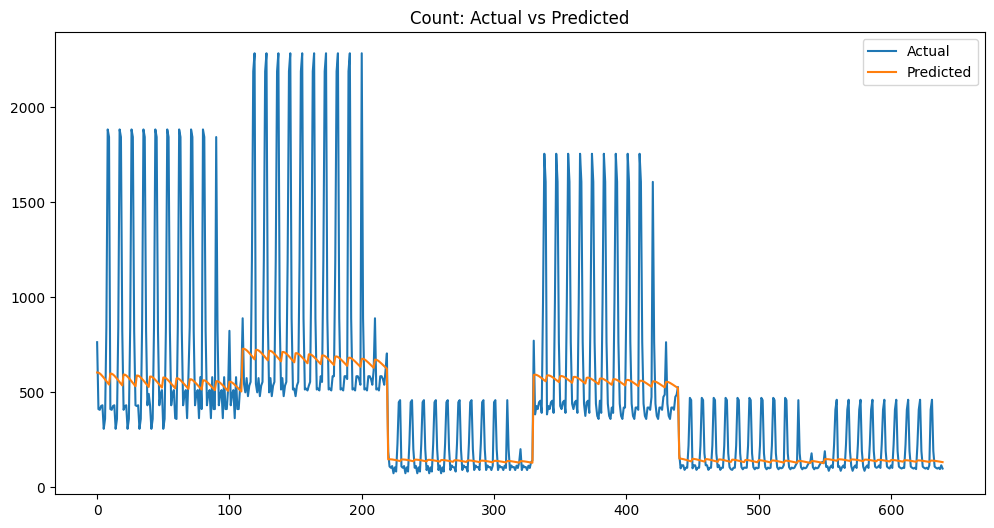

In [38]:
plot_actual_vs_pred(y_true_count, y_pred_count, "Count: Actual vs Predicted")


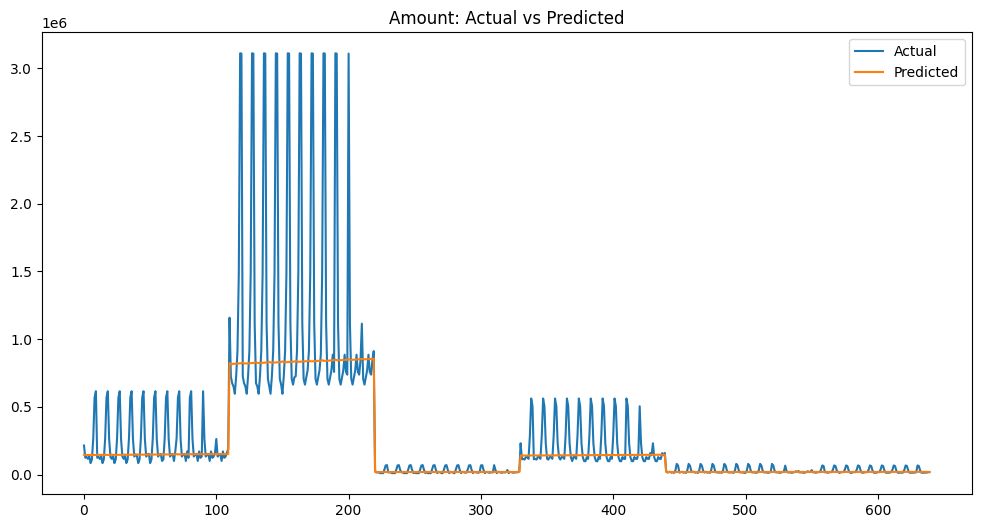

In [39]:
plot_actual_vs_pred(y_true_amount, y_pred_amount, "Amount: Actual vs Predicted")


In [40]:
def plot_residuals(true, pred, title):
    residuals = true - pred
    plt.figure(figsize=(12,6))
    plt.scatter(range(len(residuals)), residuals, s=4)
    plt.axhline(0, color="red")
    plt.title(title)
    plt.show()


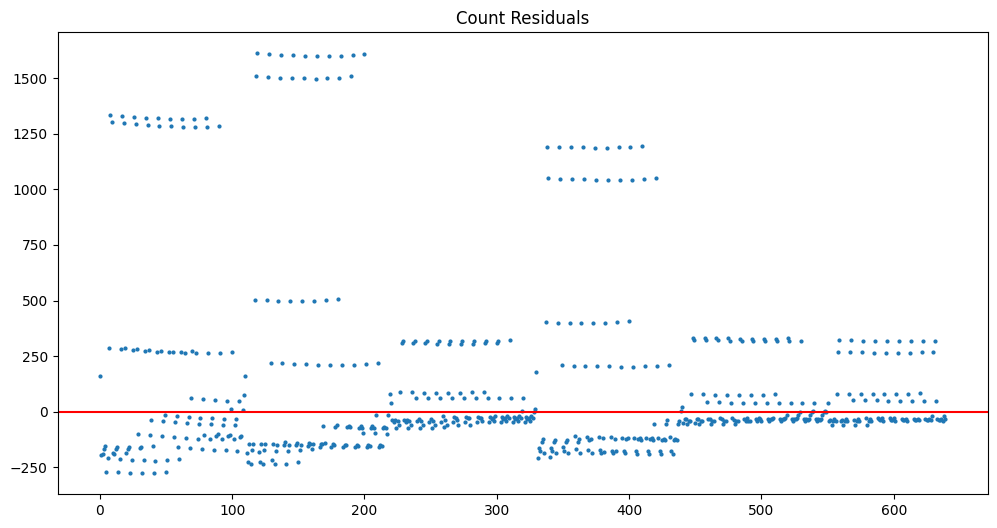

In [41]:
plot_residuals(y_true_count, y_pred_count, "Count Residuals")


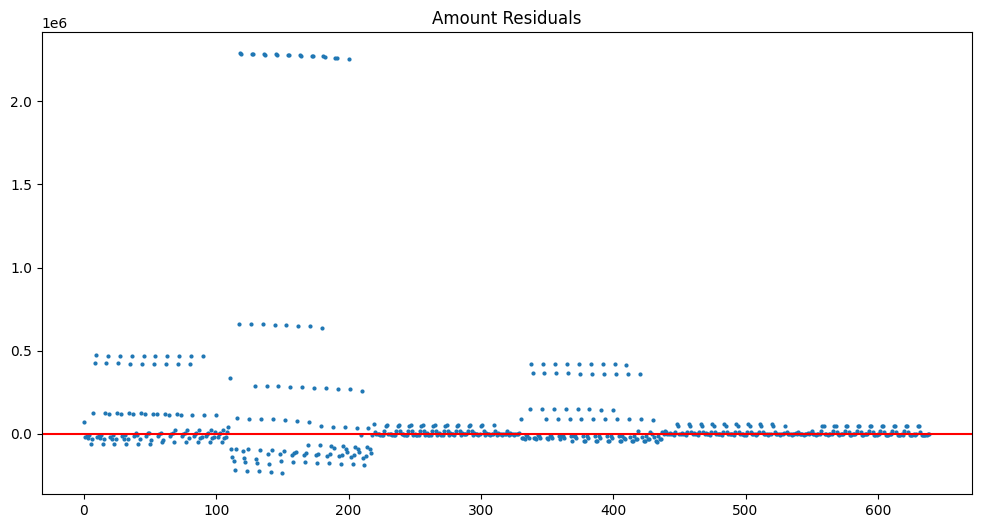

In [42]:
plot_residuals(y_true_amount, y_pred_amount, "Amount Residuals")

In [43]:
#block 8 distribution of errors
def plot_error_dist(true, pred, title):
    errors = true - pred
    plt.figure(figsize=(8,5))
    plt.hist(errors, bins=50)
    plt.title(title)
    plt.show()

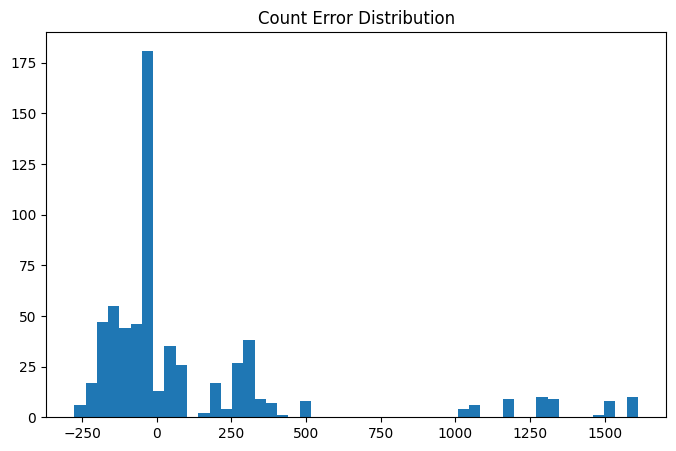

In [44]:
plot_error_dist(y_true_count, y_pred_count, "Count Error Distribution")

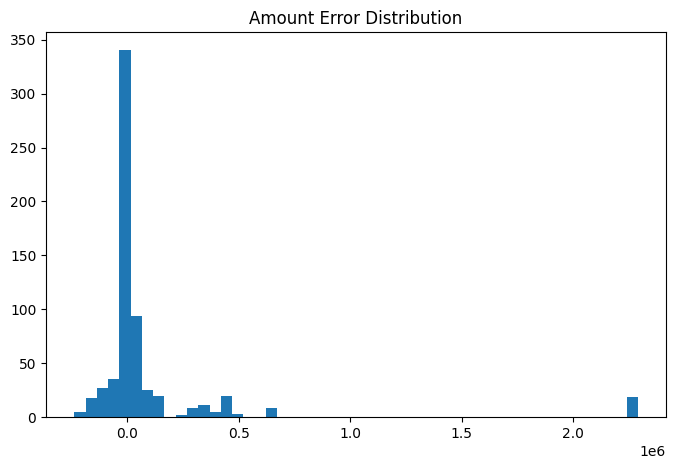

In [45]:
plot_error_dist(y_true_amount, y_pred_amount, "Amount Error Distribution")

In [79]:
df_raw = tsd_count_train.data["dataframe"]
df_raw.head()


KeyError: 'dataframe'

In [76]:
df_raw.head()


AttributeError: 'dict' object has no attribute 'head'

In [80]:
print(type(tsd_count_train))
print(dir(tsd_count_train))


<class 'pytorch_forecasting.data.timeseries.TimeSeriesDataSet'>
['__add__', '__annotations__', '__class__', '__class_getitem__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__orig_bases__', '__parameters__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slots__', '__str__', '__subclasshook__', '__weakref__', '_collate_fn', '_construct_index', '_data_to_tensors', '_get_lagged_names', '_group_ids', '_group_ids_mapping', '_is_protocol', '_overwrite_values', '_preprocess_data', '_set_target_normalizer', '_validate_data', 'add_encoder_length', 'add_relative_time_idx', 'add_target_scales', 'allow_missing_timesteps', 'categorical_encoders', 'categoricals', 'constant_fill_strategy', 'data', 'decoded_index', 'dropout_categoricals', 'encoded_constant_fill_strategy', 'filter'

In [81]:
print("TYPE:", type(tsd_count_train.data))
print("DATA KEYS:", list(tsd_count_train.data.keys()) if isinstance(tsd_count_train.data, dict) else "NOT A DICT")


TYPE: <class 'dict'>
DATA KEYS: ['reals', 'categoricals', 'groups', 'target', 'weight', 'time']


In [50]:
for x, y in val_loader_count:
    print("X keys:", x.keys())
    break

X keys: dict_keys(['encoder_cat', 'encoder_cont', 'encoder_target', 'encoder_lengths', 'decoder_cat', 'decoder_cont', 'decoder_target', 'decoder_lengths', 'decoder_time_idx', 'groups', 'target_scale'])


In [59]:
group_key = "blr_name"

biller_mapping = tsd_count_train.get_parameters()["categorical_encoders"][group_key].classes_


In [62]:
for x, y in val_loader_count:
    print("groups sample:", x["groups"][:20])
    break


groups sample: tensor([[0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1]])


In [63]:
print(tsd_count_train.group_ids)


['blr_name']


In [64]:
print(tsd_count_train.index[:20])


     time_first  time_last  time_diff_to_next  index_start  time  count  \
0             0         91                  1            0     0     92   
10            0         91                  1            1     1     92   
20            0         91                  1            2     2     92   
30            0         91                  1            3     3     92   
40            0         91                  1            4     4     92   
50            0         91                  1            5     5     92   
60            0         91                  1            6     6     92   
70            0         91                  1            7     7     92   
80            0         91                  1            8     8     92   
90            0         91                  1            9     9     92   
100           0         91                  1           10    10     92   
110           0         91                  1           11    11     92   
120           0         9

In [65]:
tsd_count_train.categorical_encoders.keys()

dict_keys(['__group_id__blr_name', 'blr_name', 'day_of_week', 'is_weekend'])

In [67]:
tsd_count_train.categorical_encoders["__group_id__blr_name"].classes_


{'BILLER_01': 0,
 'BILLER_02': 1,
 'BILLER_03': 2,
 'BILLER_04': 3,
 'BILLER_05': 4,
 'BILLER_06': 5,
 'BILLER_07': 6,
 'BILLER_08': 7,
 'BILLER_09': 8,
 'BILLER_10': 9}

In [70]:
import numpy as np
import pandas as pd

results = []

# correct encoder for group_id
group_encoder = tsd_count_train.categorical_encoders["__group_id__blr_name"]
biller_mapping = group_encoder.classes_   # array of actual biller names

for (x, y), pred in zip(val_loader_count, pred_count):

    # get encoded group ids (0, 1, 2, ...)
    biller_ids = x["groups"].numpy().reshape(-1).astype(int)

    # decode encoded ids → biller names
    biller_names = [biller_mapping[i] for i in biller_ids]

    # actual & predicted
    true_vals = y[0].numpy().reshape(-1)
    pred_vals = pred.numpy().reshape(-1)

    # append rows
    for blr, t, p in zip(biller_names, true_vals, pred_vals):
        results.append([blr, float(t), float(p)])

df_results = pd.DataFrame(results, columns=["blr_name", "actual", "predicted"])


KeyError: 0

In [69]:
import numpy as np
import pandas as pd

results = []

# Dataset references
tsd = tsd_count_train

# group names for ALL samples (length = num rows)
all_group_names = tsd.group_ids   # actual blr_name per sample

# mapping from sample idx → group_id (encoded)
index_map = tsd.index             # shape: (num_samples, 2) → [group_internal_id, time_idx]

for (x, y), pred in zip(val_loader_count, pred_count):
    
    # 1. internal group ids from batch
    internal_ids = x["groups"].numpy().reshape(-1)

    # 2. find sample indices in original dataset for this batch
    #    because dataloader samples appear in same order as dataset
    sample_idxs = x["encoder_lengths"].numpy().reshape(-1)
    
    # 3. decode internal group id using dataset.index lookup
    biller_names = [
        all_group_names[i] 
        for i in tsd.index[internal_ids, 0]  # get index rows for internal ids
    ]

    # true + predicted
    true_vals = y[0].numpy().reshape(-1)
    pred_vals = pred.numpy().reshape(-1)

    for blr, t, p in zip(biller_names, true_vals, pred_vals):
        results.append([blr, float(t), float(p)])

df_results = pd.DataFrame(results, columns=["blr_name", "actual", "predicted"])


InvalidIndexError: (array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5],
      dtype=int64), 0)

In [61]:
results = []

for (x, y), pred in zip(val_loader_count, pred_count):

    # encoded biller indices are stored in "groups"
    biller_ids = x["groups"].numpy().squeeze()  # removes extra dimension


    # decode encoded ids → biller names
    biller_names = [biller_mapping[i] for i in biller_ids]

    # true + predicted
    true_vals = y[0].numpy()
    pred_vals = pred.numpy()

    # append rows
    for blr, t, p in zip(biller_names, true_vals, pred_vals):
        results.append([blr, float(t), float(p)])

df_results = pd.DataFrame(results, columns=["blr_name", "actual", "predicted"])


KeyError: 0

In [55]:
tsd_count_train.get_parameters()["group_ids"]

['blr_name']

In [49]:
results = []

for (x, y), pred in zip(val_loader_count, pred_count):
    # get biller name/id for each batch
    blr_names = x["blr_name"]    # adjust to your field
    
    # true values
    true_vals = y[0].numpy()
    
    # predictions
    pred_vals = pred.numpy()
    
    # store row-by-row
    for blr, t, p in zip(blr_names, true_vals, pred_vals):
        results.append([blr, float(t), float(p)])

# Make DataFrame
df_results = pd.DataFrame(results, columns=["blr_name", "actual", "predicted"])


KeyError: 'blr_name'

In [48]:
#block 9 per biller RMSE
biller_rmse = df.groupby("blr_name").apply(
    lambda x: mean_squared_error(
        x["actual"], x["predicted"], squared=False
    )
)

biller_rmse.plot(kind="bar", figsize=(10,5), title="RMSE per Biller")
plt.show()


KeyError: 'actual'